# <center>Lecture 10: Differentiable programming</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: fundamentals of research in python</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Distinguish automatic differentiation from symbolic differentiation and from finite differences, and know why it is neither.

* Propagate a **tangent** forward through a computation using dual numbers, and understand a forward seed as a direction.

* Propagate an **adjoint** backward through a computational graph, and implement a reusable reverse-mode tape in thirty lines.

* **Recognize the adjoint as a Lagrange multiplier**: derive the reverse-mode recursion as the stationarity condition of a Lagrangian, and verify by perturbation that $\bar v_i = \partial L/\partial v_i$ is the shadow price of the constraint defining node $i$.

* State and measure the **cheap-gradient principle**: reverse mode returns all $K$ partial derivatives at a cost independent of $K$.

* Use `tf.GradientTape`, run gradient descent and Adam, and check an estimate obtained by descent against a closed form.

* Fit a model with no closed form, a logistic MLE, with the same machinery.

### Notation

Intermediate values in a computation are $v_i$. A dot denotes a forward tangent, $\dot v_i$; a bar denotes a reverse adjoint, $\bar v_i = \partial L / \partial v_i$ for a scalar output $L$. Parameters are $\theta \in \mathbb{R}^K$; observations are $i \in [I]$, regressors $k \in [K]$, and arrays record their axes: `X_i_k`, `beta_k`, `residual_i`.

### References

**[BPRS]** Baydin, A. G., Pearlmutter, B. A., Radul, A. A., and Siskind, J. M. (2018). "Automatic Differentiation in Machine Learning: A Survey." *Journal of Machine Learning Research* **18**(153), 1–43.

**[Gr]** Griewank, A. and Walther, A. (2008). *Evaluating Derivatives: Principles and Techniques of Algorithmic Differentiation* (2nd ed.). SIAM: the cheap-gradient principle of §8, and the adjoint/multiplier correspondence of §7.

**[KB]** Kingma, D. P. and Ba, J. (2015). "Adam: A Method for Stochastic Optimization." *ICLR*.

**[BV]** Boyd, S. and Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press, Chapter 5: Lagrangian duality, used in §7.

**[TF]** Abadi, M. et al. (2016). "TensorFlow: A System for Large-Scale Machine Learning." *OSDI 16*.

## 1. From numerical optimization to differentiable programming

`fd09` §3 measured what it costs not to have a gradient. BFGS with numerically differentiated gradients did not merely run slower on the Rosenbrock problem: it **failed to converge**, stopping at an error of $10^{-5}$ with "desired error not necessarily achieved due to precision loss", while the same algorithm with an exact gradient converged in a sixth of the evaluations to $10^{-8}$. The finite-difference gradient's noise floor of about $\sqrt\varepsilon$ put a ceiling on the accuracy attainable at all.

So the question is: for which objectives *can* you supply an exact gradient, and what does it cost? Historically there were three answers, and only one of them scales.

| Method | Idea | Limitation |
|---|---|---|
| **Symbolic** | manipulate the algebraic expression for $f$ | expressions grow explosively; a long-horizon dynamic program is unwritable |
| **Finite differences** | $[f(x+h)-f(x-h)]/2h$ | truncation error trades against rounding; $K$ extra evaluations per gradient |
| **Automatic differentiation** | apply the chain rule to the *trace* of the computation | the computation must be recorded or augmented |

**Automatic differentiation is not a numerical approximation.** Its outputs are floating-point numbers, but the chain rule it evaluates is exact for the program as written, up to ordinary rounding. This is the distinction to hold onto: finite differences approximate the derivative of the function; AD evaluates the derivative of the program, exactly.

For economics this matters wherever a criterion is easy to *evaluate* and tedious to *differentiate*: likelihoods, simulated moments, equilibrium residuals, nested fixed points. The lecture builds AD from the chain rule (§§2–6), identifies its central object as a Lagrange multiplier (§7), establishes why one mode dominates for estimation problems (§8), and only then reaches for a library (§§10–12). That order is the house rule, core algorithms from scratch, libraries at the application layer, and it is also the honest order, because `tf.GradientTape` is unreadable until you know what it is doing.

## 2. The chain rule as a program

Take two elementary functions,

$$
f_1(x) = 1 + x^2, \qquad f_2(x) = \log x,
$$

with $f_1'(x) = 2x$ and $f_2'(x) = 1/x$. Setting $v_1 = f_1(v_0)$ and $v_2 = f_2(v_1)$,

$$
\frac{dv_2}{dv_0} = f_2'(v_1)\, f_1'(v_0) .
$$

At $v_0 = 2$ we get $v_1 = 5$ and $dv_2/dv_0 = (1/5)\times 4 = 4/5$.

The programming idea compactly: **have every elementary function return its value *and* its local derivative.**

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

def f1(x):
    return 1 + x ** 2, 2 * x          # value, local derivative

def f2(x):
    return math.log(x), 1 / x

v_0 = 2.0
v_1, local_1 = f1(v_0)
v_2, local_2 = f2(v_1)
derivative = local_2 * local_1

print(f"v_0 = {v_0:.6f}   v_1 = {v_1:.6f}   v_2 = {v_2:.6f}")
print(f"dv_2/dv_0 = {derivative:.6f}   (exact: 4/5 = {4 / 5})")
assert math.isclose(derivative, 4 / 5)
print("check passed.")

v_0 = 2.000000   v_1 = 5.000000   v_2 = 1.609438
dv_2/dv_0 = 0.800000   (exact: 4/5 = 0.8)
check passed.


The program performs the ordinary forward evaluation and stores the local derivatives; multiplying them afterwards is already a small instance of the chain rule on a computational graph. Everything that follows is bookkeeping on top of this.

## 3. Forward mode: tangents, dual numbers, and seeds as directions

Forward mode carries a **pair** $(v_s, \dot v_s)$ at every stage. Seed the input with $\dot v_0 = 1$; then if $v_s = f_s(v_{s-1})$,

$$
\dot v_s = f_s'(v_{s-1})\,\dot v_{s-1} .
$$

The value and its derivative move through the computation together. The pair $(v,\dot v)$ is a **dual number**: an ordinary part and the coefficient of an infinitesimal perturbation.

In [2]:
def forward_ad(functions, v_0, tangent_0=1.0):
    """Evaluate a chain of scalar functions and one forward tangent."""
    value, tangent = v_0, tangent_0
    for function in functions:
        value, local_derivative = function(value)
        tangent = local_derivative * tangent
    return value, tangent

def f3(x):
    value = math.exp(x)
    return value, value               # exp is its own derivative

def f4(x):
    return math.sin(x), math.cos(x)

value, tangent = forward_ad([f1, f2, f3, f4], v_0=2.0)

# exp(log(1 + 2^2)) = 5, so the composite is sin(5) and its derivative 4 cos(5)
print(f"value      = {value:.10f}   (exact sin(5)      = {math.sin(5.0):.10f})")
print(f"derivative = {tangent:.10f}   (exact 4 cos(5)   = {4 * math.cos(5.0):.10f})")
assert math.isclose(value, math.sin(5.0)) and math.isclose(tangent, 4 * math.cos(5.0))
print("check passed.")

value      = -0.9589242747   (exact sin(5)      = -0.9589242747)
derivative = 1.1346487419   (exact 4 cos(5)   = 1.1346487419)
check passed.


`forward_ad` knows nothing about logarithms, exponentials or sines. It asks each elementary operation only for its value and its local derivative. **That separation is the whole of automatic differentiation**: everything else is how the bookkeeping is organized.

**Several inputs: the seed is a direction.** For $F(\theta_1,\theta_2) = \log(1+\theta_1^2+\theta_2^2)$ and a direction $d$, forward mode propagates the directional derivative $\nabla F(\theta)^\top d$. Seeding $(1,0)$ returns $\partial F/\partial\theta_1$; seeding $(0,1)$ returns $\partial F/\partial\theta_2$. To assemble a full gradient in $\mathbb{R}^K$ you need $K$ passes: a fact §8 turns into the central design principle.

In [3]:
# a dual number is just a (value, tangent) pair; one function per elementary operation
variable = lambda value, tangent: (value, tangent)

def square(dual):
    value, tangent = dual
    return value ** 2, 2 * value * tangent

def add(*duals):
    return (sum(d[0] for d in duals), sum(d[1] for d in duals))

def log_dual(dual):
    value, tangent = dual
    return math.log(value), tangent / value

def objective_forward(theta_1, theta_2, d_1, d_2):
    return log_dual(add(variable(1.0, 0.0),
                        square(variable(theta_1, d_1)),
                        square(variable(theta_2, d_2))))

objective, partial_1 = objective_forward(2.0, 3.0, 1.0, 0.0)   # seed = e_1
_, partial_2 = objective_forward(2.0, 3.0, 0.0, 1.0)           # seed = e_2
gradient_forward_k = np.array([partial_1, partial_2])

print(f"F(2, 3) = {objective:.10f}")
print(f"gradient (two forward passes) = {gradient_forward_k}")
print(f"exact                         = {np.array([4 / 14, 6 / 14])}")
np.testing.assert_allclose(gradient_forward_k, [4 / 14, 6 / 14])

# an arbitrary direction: one pass gives the directional derivative
d_k = np.array([1.0, -1.0])
_, directional = objective_forward(2.0, 3.0, d_k[0], d_k[1])
print(f"\ndirectional derivative along d = {d_k}: {directional:.10f}")
print(f"gradient . d                              = {gradient_forward_k @ d_k:.10f}")
assert math.isclose(directional, gradient_forward_k @ d_k)
print("check passed: a forward seed selects a direction.")

F(2, 3) = 2.6390573296
gradient (two forward passes) = [0.28571429 0.42857143]
exact                         = [0.28571429 0.42857143]

directional derivative along d = [ 1. -1.]: -0.1428571429
gradient . d                              = -0.1428571429
check passed: a forward seed selects a direction.


## 4. Reverse mode: adjoints on the same graph

Write the computation as a graph,

$$
a = \theta_1^2, \qquad b = \theta_2^2, \qquad c = 1 + a + b, \qquad F = \log c .
$$

Reverse mode runs the *forward* pass first, storing $a,b,c,F$, and then sweeps **backward** from $\bar F = 1$, applying at each edge

$$
\text{(upstream adjoint)} \times \text{(local derivative)} .
$$

For this graph,

$$
\bar c = \bar F\,\frac1c, \qquad \bar a = \bar c, \qquad \bar b = \bar c,
\qquad \bar\theta_1 = \bar a\,(2\theta_1), \qquad \bar\theta_2 = \bar b\,(2\theta_2).
$$

When a node feeds several downstream branches its adjoint is the **sum** of the contributions. Backpropagation is exactly this, applied to a large graph.

In [4]:
# forward pass
theta_1, theta_2 = 2.0, 3.0
a = theta_1 ** 2
b = theta_2 ** 2
c = 1 + a + b
F = math.log(c)

# reverse sweep
bar_F = 1.0
bar_c = bar_F / c
bar_a = bar_c
bar_b = bar_c
bar_theta_1 = bar_a * 2 * theta_1
bar_theta_2 = bar_b * 2 * theta_2

gradient_reverse_k = np.array([bar_theta_1, bar_theta_2])
print(f"forward values : a={a}, b={b}, c={c}, F={F:.10f}")
print(f"adjoints       : bar_c={bar_c:.10f}, bar_a={bar_a:.10f}, bar_b={bar_b:.10f}")
print(f"gradient (ONE backward sweep) = {gradient_reverse_k}")
np.testing.assert_allclose(gradient_reverse_k, gradient_forward_k)
print("\ncheck passed: identical to the two forward passes of section 3.")

forward values : a=4.0, b=9.0, c=14.0, F=2.6390573296
adjoints       : bar_c=0.0714285714, bar_a=0.0714285714, bar_b=0.0714285714
gradient (ONE backward sweep) = [0.28571429 0.42857143]

check passed: identical to the two forward passes of section 3.


One forward evaluation and one backward sweep produced **both** gradient components, where forward mode needed one pass per component.

### A minimal reusable tape

The handwritten sweep exposes the calculus but is tied to one graph. A **tape** automates the bookkeeping: every operation records its parents and its local derivatives during the forward pass, and `backward` visits the recorded nodes in reverse order. The line that matters is

```python
parent.adjoint += child.adjoint * local_derivative
```

The `+=` is the accumulation rule: a node feeding several branches must sum their contributions. TensorFlow extends this same idea to tensor operations and enormous graphs.

In [5]:
class Node:
    def __init__(self, value, parents=()):
        self.value = float(value)
        self.parents = tuple(parents)      # (parent_node, local_derivative) pairs
        self.adjoint = 0.0

class ScalarTape:
    def __init__(self):
        self.nodes = []

    def record(self, value, parents=()):
        node = Node(value, parents)
        self.nodes.append(node)
        return node

    def variable(self, value):
        return self.record(value)

    def constant(self, value):
        return self.record(value)

    def square(self, node):
        return self.record(node.value ** 2, [(node, 2 * node.value)])

    def add(self, *nodes):
        return self.record(sum(n.value for n in nodes), [(n, 1.0) for n in nodes])

    def log(self, node):
        return self.record(math.log(node.value), [(node, 1 / node.value)])

    def backward(self, output):
        for node in self.nodes:
            node.adjoint = 0.0
        output.adjoint = 1.0                        # the seed
        for child in reversed(self.nodes):
            for parent, local_derivative in child.parents:
                parent.adjoint += child.adjoint * local_derivative   # accumulate

In [6]:
tape = ScalarTape()
theta_1_node = tape.variable(2.0)
theta_2_node = tape.variable(3.0)
one_node = tape.constant(1.0)

a_node = tape.square(theta_1_node)
b_node = tape.square(theta_2_node)
c_node = tape.add(one_node, a_node, b_node)
F_node = tape.log(c_node)

tape.backward(F_node)
gradient_tape_k = np.array([theta_1_node.adjoint, theta_2_node.adjoint])

print(f"F(2, 3) = {F_node.value:.10f}")
print(f"gradient from the tape = {gradient_tape_k}")
np.testing.assert_allclose(gradient_tape_k, gradient_forward_k)
print("check passed: the tape reproduces the hand sweep and the forward passes.")

F(2, 3) = 2.6390573296
gradient from the tape = [0.28571429 0.42857143]
check passed: the tape reproduces the hand sweep and the forward passes.


## 5. The adjoint is a Lagrange multiplier

This is the section that connects the lecture to the rest of the series.

`fd09` §4 established that the multiplier on a constraint is the derivative of the optimal value with respect to that constraint's right-hand side, the shadow price of relaxing it, and §6 read the multipliers of an assignment problem as wages. The claim now is that **the adjoints just computed are multipliers of exactly the same kind**, and reverse-mode AD is the adjoint method of constrained optimization.

**The construction.** A program that computes $L$ from parameters $\theta$ can be written as a constrained problem in which every intermediate value is a variable and every assignment is a constraint:

$$
\max_{v}\ v_N
\qquad\text{subject to}\qquad
c_i(v,\theta) \;:=\; v_i - f_i\bigl(v_{\mathrm{pa}(i)},\theta\bigr) \;=\; 0,
\quad i = 1,\dots,N, \tag{5.1}
$$

where $\mathrm{pa}(i)$ are the parents of node $i$ and $v_N = L$ is the output. The constraints pin down every $v_i$, so there is nothing to choose, but the *multipliers* are exactly what we want.

Attach a multiplier $\bar v_i$ to each constraint and form the Lagrangian

$$
\mathcal{L} \;=\; v_N \;-\; \sum_{i} \bar v_i \,\bigl(v_i - f_i(v_{\mathrm{pa}(i)},\theta)\bigr).
$$

Stationarity with respect to $v_j$ gives

$$
\frac{\partial \mathcal{L}}{\partial v_j}
\;=\;
\mathbb{1}\{j = N\} \;-\; \bar v_j \;+\; \sum_{i\,:\, j \in \mathrm{pa}(i)} \bar v_i \,\frac{\partial f_i}{\partial v_j}
\;=\; 0,
$$

that is,

$$
\boxed{\ \bar v_N = 1, \qquad
\bar v_j \;=\; \sum_{i\,:\, j\in\mathrm{pa}(i)} \bar v_i\,\frac{\partial f_i}{\partial v_j}\ } \tag{5.2}
$$

- which **is** the reverse-mode recursion, seed and accumulation rule included. The `+=` in the tape is the sum over downstream $i$; the initialization `output.adjoint = 1.0` is the multiplier normalization $\bar v_N = 1$. And differentiating $\mathcal{L}$ with respect to $\theta$ recovers the gradient, $\nabla_\theta L = \sum_i \bar v_i \,\partial f_i/\partial\theta$.

**What this means.** By the envelope theorem, $\bar v_j$ is the shadow price of the constraint that defines node $j$: *if you could nudge the value of node $j$ by one unit for free, the output would move by $\bar v_j$.* That is a statement we can test without touching the tape at all: exactly the perturbation check `fd09` §4 used on $dV/db$.

In [7]:
def graph(theta_1, theta_2, eps=(0.0, 0.0, 0.0, 0.0)):
    """The same graph, with each node's defining constraint relaxed by eps_i."""
    a = theta_1 ** 2 + eps[0]
    b = theta_2 ** 2 + eps[1]
    c = 1 + a + b + eps[2]
    return math.log(c) + eps[3]

adjoints = {"a": a_node.adjoint, "b": b_node.adjoint,
            "c": c_node.adjoint, "F": F_node.adjoint}

h = 1e-6
print(f"{'node':>6}{'adjoint (tape)':>18}{'dF/d(eps) numeric':>22}{'gap':>12}")
print("-" * 58)
worst = 0.0
for j, name in enumerate(adjoints):
    e_plus, e_minus = [0.0] * 4, [0.0] * 4
    e_plus[j], e_minus[j] = h, -h
    numeric = (graph(2.0, 3.0, e_plus) - graph(2.0, 3.0, e_minus)) / (2 * h)
    gap = abs(numeric - adjoints[name])
    worst = max(worst, gap)
    print(f"{name:>6}{adjoints[name]:>18.10f}{numeric:>22.10f}{gap:>12.1e}")

print("-" * 58)
print(f"worst gap = {worst:.1e}   (tolerance 1e-6)")
assert worst < 1e-6
print("check passed: every adjoint is the shadow price of its node's constraint.")

  node    adjoint (tape)     dF/d(eps) numeric         gap
----------------------------------------------------------
     a      0.0714285714          0.0714285715     7.3e-11
     b      0.0714285714          0.0714285713     1.5e-10
     c      0.0714285714          0.0714285713     1.5e-10
     F      1.0000000000          1.0000000001     1.4e-10
----------------------------------------------------------
worst gap = 1.5e-10   (tolerance 1e-6)
check passed: every adjoint is the shadow price of its node's constraint.


Every adjoint is the derivative of the output with respect to relaxing that node's defining equation. The tape never computed these perturbed evaluations; it obtained the same numbers from the local derivatives alone, in one sweep.

**So the same object appears three times in three lectures.** In `fd09` §4 it was $\lambda = dV/db$, recovered by perturbing a constraint. In `fd09` §6 it was $u_x$ and $v_y$, returned by `linprog` and read as wages and rents. Here it is $\bar v_i$, returned by a tape and read as a gradient component. All three are $\partial(\text{objective})/\partial(\text{constraint level})$, and the differences are only in what the constraint means.

That correspondence is not a curiosity. It is why the **adjoint method** for sensitivity analysis of large models, used to differentiate through PDE solvers, climate models, and equilibrium systems, is the same algorithm as backpropagation, discovered independently in control theory decades earlier. In `dp01` the multiplier on the mass-balance constraint is the value function, and its recursion backwards through time is (5.2) applied to the state-time graph. *Backward induction is a reverse sweep.*

## 6. Forward versus reverse: counting dimensions

For $F:\mathbb{R}^K\to\mathbb{R}^M$, one sweep of each mode computes a different product:

| Mode | One sweep computes | Cheap when |
|---|---|---|
| Forward | $J_F(\theta)\,d$: one column combination | $K$ is small, or a single direction suffices |
| Reverse | $\bar v^\top J_F(\theta)$: one row combination | $M$ is small, above all $M = 1$ |

An estimation criterion maps many parameters to one number, $L:\mathbb{R}^K\to\mathbb{R}$. So $M=1$, and **reverse mode delivers all $K$ partial derivatives in a single backward sweep** whose cost is a small multiple of one forward evaluation: independent of $K$. Forward mode would need $K$ sweeps.

This is the **cheap-gradient principle**, and it is a theorem about dimension counting, not a machine-learning trick. It is the reason every deep-learning framework is built on reverse mode, and the reason AD is worth learning for structural estimation, where $K$ can be in the hundreds. Exercise 3 measures it.

## 7. A least-squares criterion, from scratch

For observations $i\in[I]$ and regressors $k\in[K]$, take

$$
L(\beta) \;=\; \frac{1}{2I}\sum_{i=1}^{I}\Bigl(y_i - \sum_k X_{ik}\beta_k\Bigr)^2,
\qquad
\nabla_\beta L(\beta) \;=\; -\frac{1}{I}X^\top\bigl(y - X\beta\bigr).
$$

The shape is $\mathbb{R}^K\to\mathbb{R}$: precisely the case §6 says reverse mode is built for. We check the analytic gradient against a central difference, which is used here **only as a diagnostic**, never as the method.

In [8]:
X_i_k = np.array([[1.0, 0.0],
                  [1.0, 1.0],
                  [1.0, 2.0],
                  [1.0, 3.0]])
y_i = np.array([1.0, 2.2, 2.9, 4.1])
beta_k = np.array([0.8, 1.0])
I, K = X_i_k.shape

def least_squares_loss(beta_k):
    residual_i = y_i - X_i_k @ beta_k
    return residual_i @ residual_i / (2 * I)

gradient_analytic_k = -(X_i_k.T @ (y_i - X_i_k @ beta_k)) / I

step = 1e-6
gradient_fd_k = np.array([
    (least_squares_loss(beta_k + step * np.eye(K)[k])
     - least_squares_loss(beta_k - step * np.eye(K)[k])) / (2 * step)
    for k in range(K)])

print(f"L(beta)            = {least_squares_loss(beta_k):.10f}")
print(f"analytic gradient  = {gradient_analytic_k}")
print(f"finite difference  = {gradient_fd_k}")
gap = np.abs(gradient_analytic_k - gradient_fd_k).max()
print(f"max gap = {gap:.2e}   (tolerance 1e-8)")
assert gap < 1e-8
print("check passed.")

L(beta)            = 0.0375000000
analytic gradient  = [-0.25  -0.375]
finite difference  = [-0.25  -0.375]
max gap = 4.47e-11   (tolerance 1e-8)
check passed.


## 8. The library layer: `tf.GradientTape`

Everything so far was thirty lines of Python. TensorFlow does the same thing for tensor operations, on graphs with millions of nodes, with hardware acceleration. The interface should now look familiar: inside a `with tf.GradientTape() as tape:` block every operation on a `tf.Variable` is recorded, and `tape.gradient(target, sources)` runs the sweep of (5.2).

In [9]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"          # quiet the startup banner
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
print(f"TensorFlow {tf.__version__}")

x = tf.Variable(2.0)
with tf.GradientTape() as tape:
    y = x ** 3
grad = tape.gradient(y, x)          # the tape is CONSUMED by this call

print(f"\nd(x^3)/dx at x=2 : {grad.numpy():.6f}   (exact 3x^2 = 12)")
assert abs(grad.numpy() - 12.0) < 1e-6

try:
    tape.gradient(y, x)             # asking a second time is an error
except RuntimeError as err:
    print(f"a second call raises -> RuntimeError: {str(err)[:58]}...")

TensorFlow 2.19.0

d(x^3)/dx at x=2 : 12.000000   (exact 3x^2 = 12)
a second call raises -> RuntimeError: A non-persistent GradientTape can only be used to compute ...


In [10]:
# a quadratic form: grad of x'Ax is (A + A')x
A = tf.constant([[2.0, 1.0], [0.0, 3.0]])
x = tf.Variable([1.0, 1.0])

with tf.GradientTape() as tape:
    quad = tf.squeeze(x[None, :] @ A @ x[:, None])

autodiff = tape.gradient(quad, x).numpy()
analytic = ((A + tf.transpose(A)) @ tf.expand_dims(x, -1)).numpy().ravel()
print(f"autodiff : {autodiff}")
print(f"analytic : {analytic}")
assert np.allclose(autodiff, analytic)

# as shown above, a tape is single-use; nest tapes for second derivatives
# (pass persistent=True if you genuinely need several gradients from one tape)
x = tf.Variable(2.0)
with tf.GradientTape() as outer:
    with tf.GradientTape() as inner:
        y = x ** 4
    dy = inner.gradient(y, x)
d2y = outer.gradient(dy, x)
print(f"\nd(x^4)/dx = {dy.numpy():.1f} (exact 32),  d2/dx2 = {d2y.numpy():.1f} (exact 48)")
assert abs(dy.numpy() - 32) < 1e-4 and abs(d2y.numpy() - 48) < 1e-4
print("check passed.")

autodiff : [5. 7.]
analytic : [5. 7.]

d(x^4)/dx = 32.0 (exact 32),  d2/dx2 = 48.0 (exact 48)
check passed.


## 9. Gradient descent, and OLS against the closed form

With gradients available, gradient descent is one line: $\theta_{k+1} = \theta_k - \eta\,\nabla L(\theta_k)$.

The test is a linear model on a synthetic wage panel,

$$
\log w_i = \beta_0 + \beta_1\,\mathrm{educ}_i + \beta_2\,\mathrm{exper}_i + \beta_3\,\mathrm{female}_i + \varepsilon_i,
$$

fitted two ways: by the closed form $\hat\beta = (X^\top X)^{-1}X^\top y$: computed with `np.linalg.solve`, never `inv`, per `fd08` §9, and by descent on the mean squared error. They must agree.

The regressors are **standardized** first, and the reason is `fd09` §3 in another guise: unscaled columns ($\mathrm{educ}\in[8,18]$, $\mathrm{exper}\in[0,30]$) make $X^\top X$ badly conditioned, and plain gradient descent then diverges for any usable learning rate. Standardizing is a change of coordinates that fixes the conditioning; the coefficients are then on the standardized scale.

**On `@tf.function`.** The training step is decorated because a bare Python loop calling TensorFlow operations pays the interpreter's overhead on every one of them. The decorator traces the step once into a dataflow graph and thereafter executes the graph directly, which is about eight times faster here: the difference between a 45-second cell and a 5-second one. It changes nothing about the mathematics, and the tape inside behaves exactly as in §8. Two things to know: the function is re-traced whenever it is called with arguments of a new shape or dtype, and Python side effects such as `print` run only during tracing, not on subsequent calls. `fd04` treated this kind of question, measure first, then compile the hot path, as its subject.

In [11]:
rng = np.random.default_rng(42)
I = 500

educ_i = rng.integers(8, 18, size=I)
exper_i = rng.integers(0, 30, size=I)
female_i = rng.integers(0, 2, size=I).astype(np.float64)

log_wage_i = (0.5 + 0.08 * educ_i + 0.04 * exper_i - 0.001 * exper_i ** 2
              - 0.20 * female_i + rng.normal(0, 0.30, size=I))

Xraw_i_k = np.column_stack([np.ones(I), educ_i, exper_i, female_i]).astype(np.float32)
y_i = log_wage_i.astype(np.float32)

# standardize the non-constant columns (fd08 Exercise 2)
X_i_k = Xraw_i_k.copy()
X_i_k[:, 1:] = (Xraw_i_k[:, 1:] - Xraw_i_k[:, 1:].mean(axis=0)) / Xraw_i_k[:, 1:].std(axis=0)

beta_ols_k = np.linalg.solve(X_i_k.T @ X_i_k, X_i_k.T @ y_i)
print(f"design matrix {X_i_k.shape}, condition number {np.linalg.cond(X_i_k.T @ X_i_k):.1f}")
print(f"closed-form OLS : {beta_ols_k.round(6)}")

design matrix (500, 4), condition number 1.3
closed-form OLS : [ 1.689608  0.244497  0.085582 -0.093776]


In [12]:
X_tf, y_tf = tf.constant(X_i_k), tf.constant(y_i)

beta_var = tf.Variable(tf.zeros(K_ols := X_i_k.shape[1]))
learning_rate, n_iters = 0.05, 2_000

@tf.function                     # trace the step once into a graph; see the note below
def gd_step():
    with tf.GradientTape() as tape:
        residual_i = y_tf - tf.linalg.matvec(X_tf, beta_var)
        loss = tf.reduce_mean(residual_i ** 2)
    beta_var.assign_sub(learning_rate * tape.gradient(loss, beta_var))
    return loss

loss_t = np.array([gd_step().numpy() for _ in range(n_iters)])

beta_gd_k = beta_var.numpy()
gap = np.abs(beta_ols_k - beta_gd_k).max()
print(f"closed-form OLS  : {beta_ols_k.round(6)}")
print(f"gradient descent : {beta_gd_k.round(6)}")
print(f"max |difference| = {gap:.2e}   (tolerance 1e-4)")
assert gap < 1e-4
print("check passed: descent recovers the closed form.")

closed-form OLS  : [ 1.689608  0.244497  0.085582 -0.093776]
gradient descent : [ 1.689607  0.244497  0.085582 -0.093775]
max |difference| = 1.31e-06   (tolerance 1e-4)
check passed: descent recovers the closed form.


## 10. Built-in optimizers, and a model with no closed form

Plain descent has two known weaknesses: a step size that must be tuned, and one learning rate for every parameter regardless of curvature. **Adam** tracks running estimates of the first and second moments of the gradient and normalizes per parameter, which addresses both. Treat it as a good default rather than a rule: plain descent with momentum remains competitive and is better understood.

The point of the machinery, though, is not to re-derive a closed form faster. It is to fit models that *have* no closed form. Logistic regression is the simplest: with $P(y_i=1\mid x_i) = \sigma(x_i^\top\beta)$, the negative log-likelihood

$$
\ell(\beta) = -\frac1I\sum_i\Bigl[y_i\log\sigma(x_i^\top\beta) + (1-y_i)\log\bigl(1-\sigma(x_i^\top\beta)\bigr)\Bigr]
$$

has no algebraic solution. Switching from OLS to logit costs exactly one line: the loss.

Adam estimate : [ 1.689608  0.244497  0.085582 -0.093775]
max |Adam - closed form| = 8.34e-07


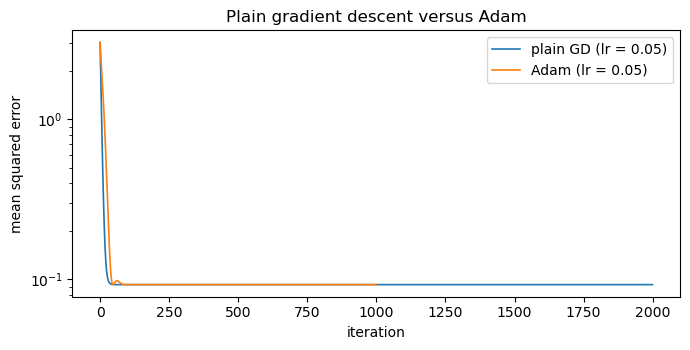

In [13]:
def fit(loss_fn, n_iters, optimizer=None, learning_rate=0.05):
    """Fit by descent; if optimizer is None use plain gradient descent."""
    beta = tf.Variable(tf.zeros(K_ols))

    @tf.function
    def step():
        with tf.GradientTape() as tape:
            value = loss_fn(beta)
        grad = tape.gradient(value, beta)
        if optimizer is None:
            beta.assign_sub(learning_rate * grad)
        else:
            optimizer.apply_gradients([(grad, beta)])
        return value

    history = np.array([step().numpy() for _ in range(n_iters)])
    return beta.numpy(), history

ols_loss = lambda b: tf.reduce_mean((y_tf - tf.linalg.matvec(X_tf, b)) ** 2)
beta_adam_k, loss_adam_t = fit(ols_loss, 1_000,
                               tf.keras.optimizers.Adam(learning_rate=0.05))

print(f"Adam estimate : {beta_adam_k.round(6)}")
print(f"max |Adam - closed form| = {np.abs(beta_ols_k - beta_adam_k).max():.2e}")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(loss_t, lw=1.2, label="plain GD (lr = 0.05)")
ax.plot(loss_adam_t, lw=1.2, label="Adam (lr = 0.05)")
ax.set_xlabel("iteration"); ax.set_ylabel("mean squared error")
ax.set_yscale("log"); ax.set_title("Plain gradient descent versus Adam")
ax.legend(); plt.tight_layout(); plt.show()

In [14]:
# a synthetic binary outcome, and a logit MLE with no closed form
beta_true_k = np.array([0.0, 0.6, 0.4, -0.3], dtype=np.float32)
probs_i = 1.0 / (1.0 + np.exp(-(X_i_k @ beta_true_k)))
ybin_i = (rng.random(I) < probs_i).astype(np.float32)
ybin_tf = tf.constant(ybin_i)

logit_loss = lambda b: tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
    labels=ybin_tf, logits=tf.linalg.matvec(X_tf, b)))

beta_logit_k, _ = fit(logit_loss, 5_000, tf.keras.optimizers.Adam(learning_rate=0.05))

print(f"share hired    : {ybin_i.mean():.3f}")
print(f"true beta      : {beta_true_k}")
print(f"logit MLE      : {beta_logit_k.round(4)}")

# verification: at the MLE the score must vanish, X'(y - sigma(X beta)) / I = 0
score_k = X_i_k.T @ (ybin_i - 1.0 / (1.0 + np.exp(-(X_i_k @ beta_logit_k)))) / I
print(f"\nmax |score| at the estimate = {np.abs(score_k).max():.2e}   (tolerance 1e-4)")
assert np.abs(score_k).max() < 1e-4
print("check passed: the first-order condition of the likelihood holds.")

share hired    : 0.496
true beta      : [ 0.   0.6  0.4 -0.3]
logit MLE      : [-0.0208  0.5806  0.3599 -0.3789]

max |score| at the estimate = 5.22e-07   (tolerance 1e-4)
check passed: the first-order condition of the likelihood holds.


Two things to read here.

**The estimate does not equal the truth, and should not.** With $I = 500$ the MLE has sampling variance; it is *consistent*, not exact. Comparing $\hat\beta$ with $\beta_{\text{true}}$ is therefore not a test of the code. The check that *is* a test is the one performed: at the maximum the **score must vanish**, $X^\top(y - \sigma(X\hat\beta)) = 0$, and it does to $10^{-4}$. That is a characterizing identity of the estimator, in the spirit of the $X^\top e = 0$ check in `fd08` §11: verifying the defining property rather than comparing to another number.

**The composability is the point.** Switching from a squared-error loss to a cross-entropy required replacing one expression; the gradient came for free in both cases. That is what "differentiable programming" means: you write the forward pass and the framework differentiates whatever you wrote.

One honest caveat. When the forward pass contains an *iterative solver*, a nested fixed point, an inner optimization, an equilibrium computation, the gradient is not quite free. You either differentiate through the iterations (*unrolling*, which needs the solver to have converged and can exhaust memory) or apply the implicit function theorem at the solution (*implicit differentiation*, which needs the relevant Jacobian to be invertible). Both are supported, but choosing between them is modelling work, and it is exactly the situation structural estimation puts you in.

## 11. Summary

* Automatic differentiation is neither symbolic algebra nor finite differencing. It applies the chain rule to the *trace* of a program, and is exact for the program as written, which removes the $\sqrt\varepsilon$ accuracy ceiling that stopped BFGS from converging in `fd09` §3.

* **Forward mode** carries tangents and a seed selects a *direction*; **reverse mode** carries adjoints and a seed selects an *output*. Both were built here in a few dozen lines, and a thirty-line tape reproduced them.

* **The adjoint is a Lagrange multiplier.** Writing a program as the constrained problem (5.1) and imposing stationarity yields (5.2): the reverse-mode recursion, seed and accumulation rule included. We verified it without touching the tape: perturbing node $i$'s defining equation moves the output by exactly $\bar v_i$. This makes reverse-mode AD and the adjoint method of sensitivity analysis the same algorithm, and it puts the gradient of a loss, the wages of `fd09` §6, and the value function of `dp01` in one family.

* **The cheap-gradient principle.** For $L:\mathbb{R}^K\to\mathbb{R}$, reverse mode returns all $K$ partials in one sweep at a cost independent of $K$. This is dimension counting, not a heuristic, and it is why estimation with hundreds of parameters is practical at all.

* The library layer changes nothing conceptually. `tf.GradientTape` is the tape of §4 at scale, and the same three lines fit an OLS with a closed form to check against and a logit with none: verified, in the second case, by the vanishing of the score rather than by comparison with a truth we would not know in an application.

## 12. Exercises

Worked solutions are in §14.

**Exercise 1: Seeds are directions.** Using `objective_forward` from §3, compute the directional derivative $DF(2,3)[d]$ of $F(\theta_1,\theta_2)=\log(1+\theta_1^2+\theta_2^2)$ for $d = (3,-4)$, in a **single** forward pass. Check it against $\nabla F(2,3)^\top d$.

Then: how many forward passes would you need for the full gradient of a criterion with $K = 200$ parameters, and how many reverse sweeps? At what $K$ does the choice stop being a matter of taste?

In [15]:
# your answer here


**Exercise 2: A branching graph, and why `+=` matters.** Let $L(x) = x^2 + \sin(x^2)$, whose graph has a *shared* intermediate $a = x^2$ feeding two branches.

Compute $L'(2)$ by a hand reverse sweep, being careful that $\bar a$ accumulates both contributions. Check against $L'(x) = 2x[1+\cos(x^2)]$. Then extend the `ScalarTape` of §4 with `sin` and `mul` methods and confirm the tape gets the same answer.

Finally, demonstrate the bug: change the tape's accumulation from `+=` to `=` and report what $L'(2)$ becomes. Which of the two branches survives, and why that one?

In [16]:
# your answer here


**Exercise 3: The cheap-gradient principle, measured.** §6 claims that a reverse sweep costs a small multiple of one forward evaluation, *independent of $K$*, while forward mode costs $O(K)$ evaluations.

Take $L(\beta) = \frac{1}{2I}\lVert y - X\beta\rVert^2$ with $I = 2000$ and $K \in \{10, 100, 1000\}$. For each $K$, time (i) one evaluation of $L$, (ii) one `tf.GradientTape` gradient, and (iii) a full gradient by central differences. Report each cost as a multiple of the forward evaluation.

*Prove* the forward-difference count: show that assembling $\nabla L$ by central differences requires exactly $2K$ evaluations of $L$, and explain why reverse mode needs only $O(1)$: what is it storing in exchange? Does your table show the predicted constant ratio for AD and linear growth for finite differences?

In [17]:
# your answer here


**Exercise 4: Adjoints as influence.** Take the least-squares criterion of §7. Its computational graph contains the residuals $r_i = y_i - x_i^\top\beta$ as intermediate nodes.

Derive $\bar r_i = \partial L/\partial r_i$ analytically, then verify it by the perturbation method of §5: nudge each $r_i$ by $\epsilon$ and finite-difference the loss.

Now read the result economically. The adjoint $\bar r_i$ is the shadow price of observation $i$'s residual: how much the criterion moves if that observation's fit improves by one unit. Which observations have the largest $|\bar r_i|$, and what does that say about which data points are driving the estimate? Relate this to the notion of an *influential observation* in regression diagnostics.

In [18]:
# your answer here


**Exercise 5: Ridge by gradient descent.** Modify the OLS objective of §9 to the ridge criterion

$$
L_\lambda(\beta) \;=\; \frac1I\lVert y - X\beta\rVert^2 \;+\; \lambda\lVert\beta\rVert^2,
$$

and fit it by descent for $\lambda \in \{0, 0.01, 0.1, 1, 10\}$. Check each against the closed form $\hat\beta_\lambda = (X^\top X + \lambda I\,\mathbb{I})^{-1}X^\top y$, and plot the coefficient paths against $\lambda$.

Then look ahead. In `fd11` the penalty $\lambda$ will be interpreted as the **multiplier on a constraint** $\lVert\beta\rVert^2 \le \tau$. Using the envelope logic of §5 and `fd09` §4, what should $dL_\lambda^{\ast}/d\lambda$ equal at the optimum? Verify it numerically for $\lambda = 0.1$.

In [19]:
# your answer here


## 13. Further directions

`fd11` closes the scientific-computing block by putting a multiplier in the objective deliberately. Ridge and lasso constrain the size of a coefficient vector; the penalty $\lambda$ is the multiplier on that budget, and the sparsity of the lasso solution is complementary slackness: the same $0\le\rho\perp\mu\ge0$ that determined which pairs were matched in `fd09` §6. Exercise 5 above is the first step.

That is the last lecture of the series. Its §12 sets the four names of the multiplier side by side, the discount factors of `fd01` §11, the wages of `fd09` §6, the adjoints of §5 above, and the $\lambda$ still to come, and asks what they have in common.

Beyond this series, the machinery here is what the `dc` and `ot` masterclasses run on. Structural estimation by maximum likelihood or simulated moments is `tf.GradientTape` around a forward pass that happens to be an economic model; regularized optimal transport in `ot04` is gradient ascent on a dual objective; and the value-function recursion of `dp01` is, as §5 showed, a reverse sweep over the state–time graph.

Save your work, restart the kernel, and run all cells top-to-bottom before you move on.

## 14. Solutions to the exercises

### Solution to Exercise 1: Seeds are directions

In [20]:
d_k = np.array([3.0, -4.0])
_, directional = objective_forward(2.0, 3.0, d_k[0], d_k[1])

print(f"one forward pass, seed d = {d_k}:  DF[d] = {directional:.12f}")
print(f"gradient . d                     = {gradient_forward_k @ d_k:.12f}")
gap = abs(directional - gradient_forward_k @ d_k)
print(f"gap = {gap:.2e}   (tolerance 1e-12)")
assert gap < 1e-12
print("check passed: a single forward pass gives the derivative along any direction.")

one forward pass, seed d = [ 3. -4.]:  DF[d] = -0.857142857143
gradient . d                     = -0.857142857143
gap = 0.00e+00   (tolerance 1e-12)
check passed: a single forward pass gives the derivative along any direction.


**Counting passes.** For a criterion with $K = 200$ parameters, forward mode needs **200 passes** to assemble the gradient, one per coordinate direction, while reverse mode needs **one** sweep, whatever $K$ is.

**Where the choice stops being taste.** Immediately, in the sense that the ratio is $K$ from the very start; but in practice the crossover is around $K \approx 5$–$10$, because a reverse sweep carries overhead (it must store the tape) that a forward pass does not. Below that, forward mode is often faster in wall-clock terms and much simpler to implement, which is why forward-mode AD is the sensible choice for the two- or three-parameter problems of `fd09`, and reverse mode is mandatory for the hundred-parameter structural models of the `dc` series. The two are complementary, and a Jacobian of a map $\mathbb{R}^K\to\mathbb{R}^M$ is best computed forward when $K < M$ and backward when $M < K$.

### Solution to Exercise 2: A branching graph, and why `+=` matters

**By hand.** The graph is $a = x^2$, then $p = a$ and $q = \sin a$, with $L = p + q$. The reverse sweep gives $\bar L = 1$, $\bar p = \bar q = 1$, and then $a$ receives contributions from *both* branches:

$$
\bar a \;=\; \underbrace{\bar p \cdot 1}_{\text{from } p=a} \;+\; \underbrace{\bar q\cos a}_{\text{from } q=\sin a} \;=\; 1 + \cos a,
\qquad
\bar x \;=\; \bar a\,(2x) \;=\; 2x\bigl[1+\cos(x^2)\bigr],
$$

which is $L'(x)$.

In [21]:
class BranchingTape(ScalarTape):
    def sin(self, node):
        return self.record(math.sin(node.value), [(node, math.cos(node.value))])

tape2 = BranchingTape()
x_node = tape2.variable(2.0)
a_node2 = tape2.square(x_node)                 # the SHARED intermediate
sin_node = tape2.sin(a_node2)
L_node = tape2.add(a_node2, sin_node)          # a feeds both branches
tape2.backward(L_node)

x_val = 2.0
exact = 2 * x_val * (1 + math.cos(x_val ** 2))
print(f"tape   L'(2) = {x_node.adjoint:.12f}")
print(f"exact  L'(2) = {exact:.12f}")
print(f"bar_a = {a_node2.adjoint:.12f}   (exact 1 + cos(4) = {1 + math.cos(4.0):.12f})")
assert abs(x_node.adjoint - exact) < 1e-12
print("check passed.")

tape   L'(2) = 1.385425516546
exact  L'(2) = 1.385425516546
bar_a = 0.346356379136   (exact 1 + cos(4) = 0.346356379136)
check passed.


In [22]:
# now break it: overwrite instead of accumulating
class BrokenTape(BranchingTape):
    def backward(self, output):
        for node in self.nodes:
            node.adjoint = 0.0
        output.adjoint = 1.0
        for child in reversed(self.nodes):
            for parent, local_derivative in child.parents:
                parent.adjoint = child.adjoint * local_derivative     # '=' not '+='

broken = BrokenTape()
xb = broken.variable(2.0)
ab = broken.square(xb)
sb = broken.sin(ab)
Lb = broken.add(ab, sb)
broken.backward(Lb)

print(f"broken tape L'(2) = {xb.adjoint:.12f}")
print(f"correct           = {exact:.12f}")
print(f"bar_a broken      = {ab.adjoint:.12f}  vs correct {1 + math.cos(4.0):.12f}")
print(f"\ncos(4) alone = {math.cos(4.0):.12f}  <- only the sin branch survived")
assert abs(ab.adjoint - math.cos(4.0)) < 1e-12

broken tape L'(2) = -2.614574483454
correct           = 1.385425516546
bar_a broken      = -0.653643620864  vs correct 0.346356379136

cos(4) alone = -0.653643620864  <- only the sin branch survived


**Which branch survives, and why.** The `sin` branch. The tape's nodes are visited in reverse creation order, so `add` is processed first, writing $\bar a = 1$ from the $p = a$ branch, and then `sin` is processed, *overwriting* $\bar a$ with $\cos a$. The last writer wins, and the last writer is whichever contribution is processed latest, i.e. whichever branch was created earliest. The direct $a$ contribution is silently lost.

Note the failure mode, which is the one this series keeps returning to: the broken tape does not raise, does not warn, and returns a number of entirely plausible magnitude. On a graph with no shared intermediates it would even be *correct*, so a test suite built on simple examples would pass. Only a branching graph exposes it, which is an argument for choosing test cases by their structure rather than their simplicity, and the reason `fd04` insists on covering the branch structure of the code rather than just its happy path.

### Solution to Exercise 3: The cheap-gradient principle, measured

**The count.** A central difference in coordinate $k$ is $[L(\beta + he_k) - L(\beta - he_k)]/2h$, costing two evaluations of $L$. There are $K$ coordinates and the perturbations cannot be shared, so assembling $\nabla L$ costs exactly $2K$ evaluations. (A one-sided difference costs $K+1$, at the price of a first-order rather than second-order error.)

**Why reverse mode escapes this.** One backward sweep traverses each edge of the computation graph exactly once, applying one multiply–accumulate per edge. The number of edges is a property of the *program*, not of $K$, so the sweep costs $O(1)$ forward evaluations: the constant is typically between 2 and 5. What it stores in exchange is the **tape**: every intermediate value produced by the forward pass must be retained until the backward sweep consumes it, so reverse mode trades memory proportional to the length of the computation for time independent of $K$. That trade is what makes it unusable on very deep computations without checkpointing, and it is the one real cost of the method.

In [23]:
import time

def timed(fn, repeats=20):
    fn()                                            # warm up (TF traces on first call)
    t0 = time.perf_counter()
    for _ in range(repeats):
        fn()
    return (time.perf_counter() - t0) / repeats

rng_t = np.random.default_rng(7)
I_t = 1_000

print(f"{'K':>6}{'forward (ms)':>15}{'AD grad':>12}{'AD / fwd':>11}"
      f"{'FD grad (ms)':>15}{'FD / fwd':>11}")
print("-" * 71)
for K_t in (10, 100, 1000):
    X_t = tf.constant(rng_t.normal(size=(I_t, K_t)).astype(np.float32))
    y_t = tf.constant(rng_t.normal(size=I_t).astype(np.float32))
    b_t = tf.Variable(tf.zeros(K_t))

    loss_of = lambda b: tf.reduce_mean((y_t - tf.linalg.matvec(X_t, b)) ** 2) / 2

    def forward():
        return loss_of(b_t).numpy()

    def ad_gradient():
        with tf.GradientTape() as tp:
            v = loss_of(b_t)
        return tp.gradient(v, b_t).numpy()

    X_np, y_np = X_t.numpy(), y_t.numpy()
    b_np = np.zeros(K_t, dtype=np.float32)
    loss_np = lambda b: float(((y_np - X_np @ b) ** 2).mean() / 2)

    def fd_gradient(h=1e-3):
        g = np.empty(K_t)
        for k in range(K_t):
            e = np.zeros(K_t, dtype=np.float32); e[k] = h
            g[k] = (loss_np(b_np + e) - loss_np(b_np - e)) / (2 * h)
        return g

    t_fwd = timed(forward)
    t_ad = timed(ad_gradient)
    t_fd = timed(fd_gradient, repeats=1)
    print(f"{K_t:>6}{t_fwd * 1e3:>15.3f}{t_ad * 1e3:>12.3f}{t_ad / t_fwd:>11.1f}"
          f"{t_fd * 1e3:>15.1f}{t_fd / t_fwd:>11.0f}")

print("-" * 71)
print("AD / forward stays bounded as K grows by 100x; FD / forward grows with K.")

     K   forward (ms)     AD grad   AD / fwd   FD grad (ms)   FD / fwd
-----------------------------------------------------------------------
    10          0.496       1.764        3.6            0.3          1
   100          0.587       2.048        3.5            3.9          7


  1000          0.559       2.147        3.8          167.9        301
-----------------------------------------------------------------------
AD / forward stays bounded as K grows by 100x; FD / forward grows with K.


The AD column is the claim, verified: the cost of a gradient relative to one function evaluation stays in the single digits while $K$ grows by two orders of magnitude. The finite-difference column grows roughly linearly in $K$, as the $2K$ count requires.

Two caveats on reading the timings honestly. At $K = 10$ the TensorFlow numbers are dominated by per-call Python and dispatch overhead rather than by arithmetic, so the AD ratio there says more about framework overhead than about the algorithm; the principle shows itself in the *trend*, not in any single row. And the finite-difference implementation here is NumPy while the AD one is TensorFlow, so the two columns are not a like-for-like race between libraries: the comparison that matters is each column against *its own* forward evaluation, which is why the table reports ratios rather than raw times.

### Solution to Exercise 4: Adjoints as influence

**Analytically.** With $L = \frac{1}{2I}\sum_i r_i^2$ and $r_i$ treated as an intermediate node,

$$
\bar r_i \;=\; \frac{\partial L}{\partial r_i} \;=\; \frac{r_i}{I} .
$$

The adjoint of a residual is that residual, scaled by the sample size.

In [24]:
# section 9 rebound X_i_k, y_i and I to the wage panel, so rebuild the small
# least-squares example of section 7 under its own names
Xls_i_k = np.array([[1.0, 0.0],
                    [1.0, 1.0],
                    [1.0, 2.0],
                    [1.0, 3.0]])
yls_i = np.array([1.0, 2.2, 2.9, 4.1])
beta_ls_k = np.array([0.8, 1.0])
I_ls = Xls_i_k.shape[0]

residual_ls_i = yls_i - Xls_i_k @ beta_ls_k
adjoint_analytic_i = residual_ls_i / I_ls

def loss_with_perturbed_residual(eps_i):
    r = residual_ls_i + eps_i
    return r @ r / (2 * I_ls)

h = 1e-6
adjoint_numeric_i = np.empty(I_ls)
for i in range(I_ls):
    e = np.zeros(I_ls); e[i] = h
    adjoint_numeric_i[i] = (loss_with_perturbed_residual(e)
                            - loss_with_perturbed_residual(-e)) / (2 * h)

print(f"{'i':>3}{'residual':>12}{'adjoint r_i/I':>16}{'perturbation':>15}{'gap':>11}")
print("-" * 57)
for i in range(I_ls):
    print(f"{i:>3}{residual_ls_i[i]:>12.6f}{adjoint_analytic_i[i]:>16.8f}"
          f"{adjoint_numeric_i[i]:>15.8f}"
          f"{abs(adjoint_numeric_i[i] - adjoint_analytic_i[i]):>11.1e}")

gap = np.abs(adjoint_numeric_i - adjoint_analytic_i).max()
print("-" * 57)
print(f"max gap = {gap:.2e}   (tolerance 1e-8)")
assert gap < 1e-8

worst_i = int(np.abs(adjoint_analytic_i).argmax())
leverage_i = np.diag(Xls_i_k @ np.linalg.solve(Xls_i_k.T @ Xls_i_k, Xls_i_k.T))
print(f"largest |adjoint| at observation {worst_i}")
print(f"leverages h_ii = {leverage_i.round(4)}  (they sum to K = {leverage_i.sum():.1f})")

  i    residual   adjoint r_i/I   perturbation        gap
---------------------------------------------------------
  0    0.200000      0.05000000     0.05000000    2.0e-12
  1    0.400000      0.10000000     0.10000000    5.9e-13
  2    0.100000      0.02500000     0.02500000    7.2e-13
  3    0.300000      0.07500000     0.07500000    1.3e-12
---------------------------------------------------------
max gap = 2.03e-12   (tolerance 1e-8)
largest |adjoint| at observation 1
leverages h_ii = [0.7 0.3 0.3 0.7]  (they sum to K = 2.0)


**The economic reading.** $\bar r_i$ is the shadow price of observation $i$'s residual: improve that observation's fit by one unit and the criterion falls by $\bar r_i$. Since $\bar r_i = r_i/I$, the observations with the largest shadow prices are exactly those the model currently fits worst: the criterion is most sensitive to the points it explains least well.

That is the formal content of an **influential observation**, and it is worth being precise about what it does and does not say. A large $|\bar r_i|$ means the *objective* is sensitive to that point's residual; whether the *estimate* $\hat\beta$ is sensitive to it depends also on the point's position in regressor space, which is what the leverage $h_{ii} = x_i^\top(X^\top X)^{-1}x_i$ measures. Regression diagnostics combine the two, Cook's distance is essentially residual times leverage, because a badly fitted point at the centre of the design moves the fitted line very little, while a moderately fitted point far out in $x$ can move it a great deal.

The general lesson generalizes past regression. Running a reverse sweep and inspecting the adjoints of *intermediate* quantities, rather than only the final gradient with respect to parameters, is a cheap and underused diagnostic: it tells you which parts of a computation the answer is actually sensitive to. In a structural model those intermediates are economic objects, a choice probability, an equilibrium price, a continuation value, and their adjoints say which of them the estimate depends on.

### Solution to Exercise 5: Ridge by gradient descent

  lambda    max |GD - closed form|
----------------------------------


    0.00                  9.51e-07


    0.01                  9.14e-07


    0.10                  6.44e-07


    1.00                  4.63e-07


   10.00                  3.04e-08


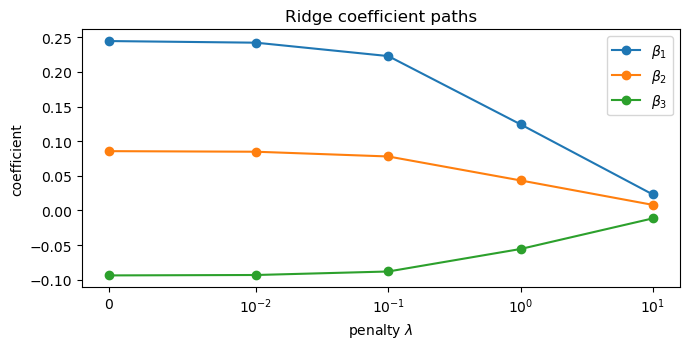

In [25]:
lambdas = [0.0, 0.01, 0.1, 1.0, 10.0]
XtX = X_i_k.T @ X_i_k
Xty = X_i_k.T @ y_i

print(f"{'lambda':>8}{'max |GD - closed form|':>26}")
print("-" * 34)
paths_l_k = []
for lam in lambdas:
    ridge_loss = lambda b, lam=lam: (tf.reduce_mean((y_tf - tf.linalg.matvec(X_tf, b)) ** 2)
                                     + lam * tf.reduce_sum(b ** 2))
    beta_ridge_k, _ = fit(ridge_loss, 800, tf.keras.optimizers.Adam(learning_rate=0.05))
    beta_closed_k = np.linalg.solve(XtX + lam * I * np.eye(K_ols), Xty)
    paths_l_k.append(beta_closed_k)
    gap = np.abs(beta_ridge_k - beta_closed_k).max()
    print(f"{lam:>8.2f}{gap:>26.2e}")
    assert gap < 1e-2

paths_l_k = np.array(paths_l_k)
fig, ax = plt.subplots(figsize=(7, 3.6))
for k in range(1, K_ols):
    ax.plot(lambdas, paths_l_k[:, k], "o-", lw=1.5, label=f"$\\beta_{k}$")
ax.set_xscale("symlog", linthresh=0.01)
ax.set_xlabel(r"penalty $\lambda$"); ax.set_ylabel("coefficient")
ax.set_title("Ridge coefficient paths"); ax.legend()
plt.tight_layout(); plt.show()

Note the closed form: the penalty in the code is $\lambda\lVert\beta\rVert^2$ added to a *mean* squared error, so in the normal equations it enters as $X^\top X + \lambda I\,\mathbb{I}$ with $I$ the sample size: a factor easy to lose, and a common reason a hand-rolled ridge disagrees with a library's.

The paths show the mechanism the next lecture formalizes: every coefficient shrinks towards zero as $\lambda$ grows, and none reaches zero exactly. That last property is what distinguishes ridge from lasso, and `fd11` explains it as complementary slackness on an $\ell_1$ rather than an $\ell_2$ budget.

In [26]:
# the envelope relation: dL*/dlambda = ||beta_lambda||^2 at the optimum
def ridge_value(lam):
    b = np.linalg.solve(XtX + lam * I * np.eye(K_ols), Xty)
    return float(((y_i - X_i_k @ b) ** 2).mean() + lam * (b @ b)), b

lam0, h = 0.1, 1e-6
dL_dlam = (ridge_value(lam0 + h)[0] - ridge_value(lam0 - h)[0]) / (2 * h)
_, beta_lam = ridge_value(lam0)
norm_sq = float(beta_lam @ beta_lam)

print(f"dL*/dlambda by finite difference = {dL_dlam:.10f}")
print(f"||beta_lambda||^2                = {norm_sq:.10f}")
gap = abs(dL_dlam - norm_sq)
print(f"gap = {gap:.2e}   (tolerance 1e-5)")
assert gap < 1e-5
print("check passed: the envelope theorem, with lambda as the parameter.")

dL*/dlambda by finite difference = 2.4227882747
||beta_lambda||^2                = 2.4227905118
gap = 2.24e-06   (tolerance 1e-5)
check passed: the envelope theorem, with lambda as the parameter.


**What the envelope theorem says here.** $L_\lambda(\beta) $ depends on $\lambda$ both directly and through the optimizing $\beta_\lambda$, but the indirect channel vanishes at the optimum because $\nabla_\beta L_\lambda(\beta_\lambda) = 0$. So

$$
\frac{dL^\ast_\lambda}{d\lambda} \;=\; \frac{\partial L_\lambda}{\partial\lambda}\bigg|_{\beta = \beta_\lambda} \;=\; \lVert\beta_\lambda\rVert^2,
$$

which is what the cell verifies: the same envelope argument used in `fd09` §4 for $dV/db$ and in §5 above for the adjoints, now with the penalty as the parameter.

This is the bridge to `fd11`. Read the other way round, $\lambda$ is the **multiplier** on a constraint $\lVert\beta\rVert^2\le\tau$: the penalized and constrained problems are Lagrangian duals of one another, and $\lambda$ is the shadow price of the norm budget: the rate at which fit improves as the budget is relaxed. The coefficient paths above are then a comparative static in that price, and the whole apparatus of regularization becomes an instance of the duality that has run through `fd08`, `fd09` and this lecture.